# MCMC Rashomon Set Sampling on COMPAS

Sample models from the Rashomon set defined by misclassification error:

$$R(\varepsilon) = \{ w : \text{error}(w) \leq (1 + \varepsilon) \cdot \text{best\_error} \}$$

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
import pickle as pkl
import numpy as np
import pandas as pd
import torch
from new_method_scripts.mcmc_rashomon import (
    MCMCRashomonSampler, RashomonResult, binarize_data, plot_gam_shapes, make_diversity_prediction_hamming,diversity_support_jaccard)
from new_method_scripts.run_diversity_experiment import select_features_l1

## 1. Load and prepare COMPAS data

In [2]:
data = pd.read_csv('/usr/xtmp/vb97/FRL_Rashomon_Set/falling-models/data/benchmark/compas.csv')
print(f"Dataset shape: {data.shape}")
print(f"Columns: {list(data.columns)}")
data.head()

Dataset shape: (6907, 8)
Columns: ['sex=female', 'age', 'juv_fel_count', 'juv_misd_count', 'juvenile_crimes', 'priors_count', 'current_charge_degree=felony', 'two_year_recid']


,sex=female,age,juv_fel_count,juv_misd_count,juvenile_crimes,priors_count,current_charge_degree=felony,two_year_recid
0,0,69,0,0,0,0,1,0
1,0,34,0,0,0,0,1,1
2,0,24,0,0,1,4,1,1
3,0,44,0,0,0,0,0,0
4,0,41,0,0,0,14,1,1


In [3]:
X, y, feature_names, feature_groups = binarize_data(data)
X,feature_names,feature_groups = select_features_l1(X,y,feature_names,feature_groups)

print(f"X shape: {X.shape}  (n={X.shape[0]}, p={X.shape[1]} incl. intercept)")
print(f"  -> {len(feature_groups)} original features expanded to {X.shape[1]-1} binary thresholds + intercept")
print(f"y: {np.unique(y, return_counts=True)}")
print(f"Base rate: {y.mean():.3f}")
print(f"\nFeature groups:")
for feat, indices in feature_groups.items():
    print(f"  {feat}: {len(indices)} thresholds (cols {indices[0]}-{indices[-1]})")

/usr/project/xtmp/vb97/GAM_Rashomon_Sets/gam-rashoman-set/new_method_scripts/binarize_augmented_datasets.py:47: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[colnames[j]+'<='+str(ts[j][s])] = 1


(6907, 59)
X shape: (6907, 59)  (n=6907, p=59 incl. intercept)
  -> 7 original features expanded to 58 binary thresholds + intercept
y: (array([0., 1.]), array([3711, 3196]))
Base rate: 0.463

Feature groups:
  age: 26 thresholds (cols 3-56)
  juv_fel_count: 3 thresholds (cols 28-57)
  juv_misd_count: 3 thresholds (cols 30-32)
  juvenile_crimes: 3 thresholds (cols 33-35)
  priors_count: 19 thresholds (cols 36-54)
  sex=female: 1 thresholds (cols 55-55)
  current_charge_degree=felony: 1 thresholds (cols 58-58)


## 2. Run MCMC Rashomon Sampler

In [17]:
sampler = MCMCRashomonSampler(
    X, y,
    eps=0.2,                        # 5% tolerance on misclassification error
    sigma2=0.1,                     # prior variance (= C in sklearn)
    p_feat=0.01,                     # prior prob of including each feature (sparse)
    feature_groups=feature_groups,   # enables group-level proposals
)

print(X.shape)

(6907, 59)


In [18]:
result = sampler.sample(
    n_steps=3000,
    burn_in=500,
    target_models=100,
    beta=0.5,
    proposal='mixture',
    mh_variant='standard',
    ellipsoid_augment=False,
    repulsion_weight=0,
    diversity_fn = 'monotonicity_entropy',
    finetune_coordinate=False)

# result = pkl.load(open('result_mcmc.pkl', 'rb'))

Initial support: 32 features, error: 0.3145, nll: 4136.80


MH sampling:   0%|          | 1/3000 [00:01<1:21:14,  1.63s/it]

Accepted:  32


MH sampling:   0%|          | 2/3000 [00:03<1:15:32,  1.51s/it]

Accepted:  32


...

Accepted:  32


MH sampling:   0%|          | 5/3000 [00:06<1:04:38,  1.29s/it]

Accepted:  31


MH sampling:   0%|          | 7/3000 [00:10<1:12:48,  1.46s/it]


KeyboardInterrupt: 

## 3. Inspect results

In [6]:
print(f"Models in Rashomon set : {result.n_accepted}")
print(f"Total explored         : {result.n_explored}")
print(f"Best error             : {result.best_error:.4f}")
print(f"Error bound (1+eps)*   : {result.error_bound:.4f}")
print(f"MH acceptance rate     : {result.acceptance_rate:.2%}")
print(f"Runtime                : {result.runtime:.1f}s")

# with open('result_mcmc.pkl', 'wb') as f:
#     pkl.dump(result,f)

Models in Rashomon set : 47
Total explored         : 294
Best error             : 0.0759
Error bound (1+eps)*   : 0.1139
MH acceptance rate     : 51.37%
Runtime                : 324.4s


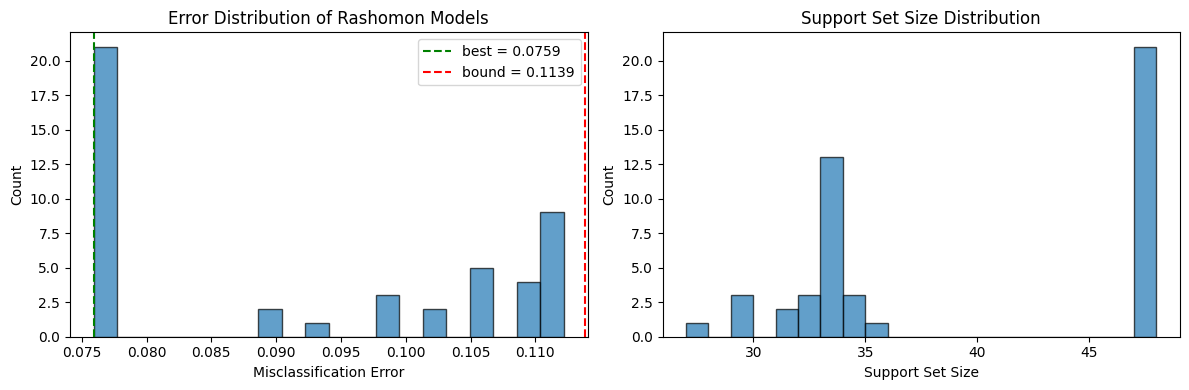

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Error distribution
axes[0].hist(result.errors, bins=20, edgecolor='black', alpha=0.7)
axes[0].axvline(result.best_error, color='green', linestyle='--', label=f'best = {result.best_error:.4f}')
axes[0].axvline(result.error_bound, color='red', linestyle='--', label=f'bound = {result.error_bound:.4f}')
axes[0].set_xlabel('Misclassification Error')
axes[0].set_ylabel('Count')
axes[0].set_title('Error Distribution of Rashomon Models')
axes[0].legend()

# Support set sizes
sizes = [len(s) for s in result.support_sets]
axes[1].hist(sizes, bins=range(min(sizes), max(sizes) + 2), edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Support Set Size')
axes[1].set_ylabel('Count')
axes[1].set_title('Support Set Size Distribution')

plt.tight_layout()
plt.show()

## 3b. GAM Shape Functions

Each subplot shows one original feature's contribution to the predicted logit.
Red curves are all Rashomon-set models; the dark gray curve is the optimal model.

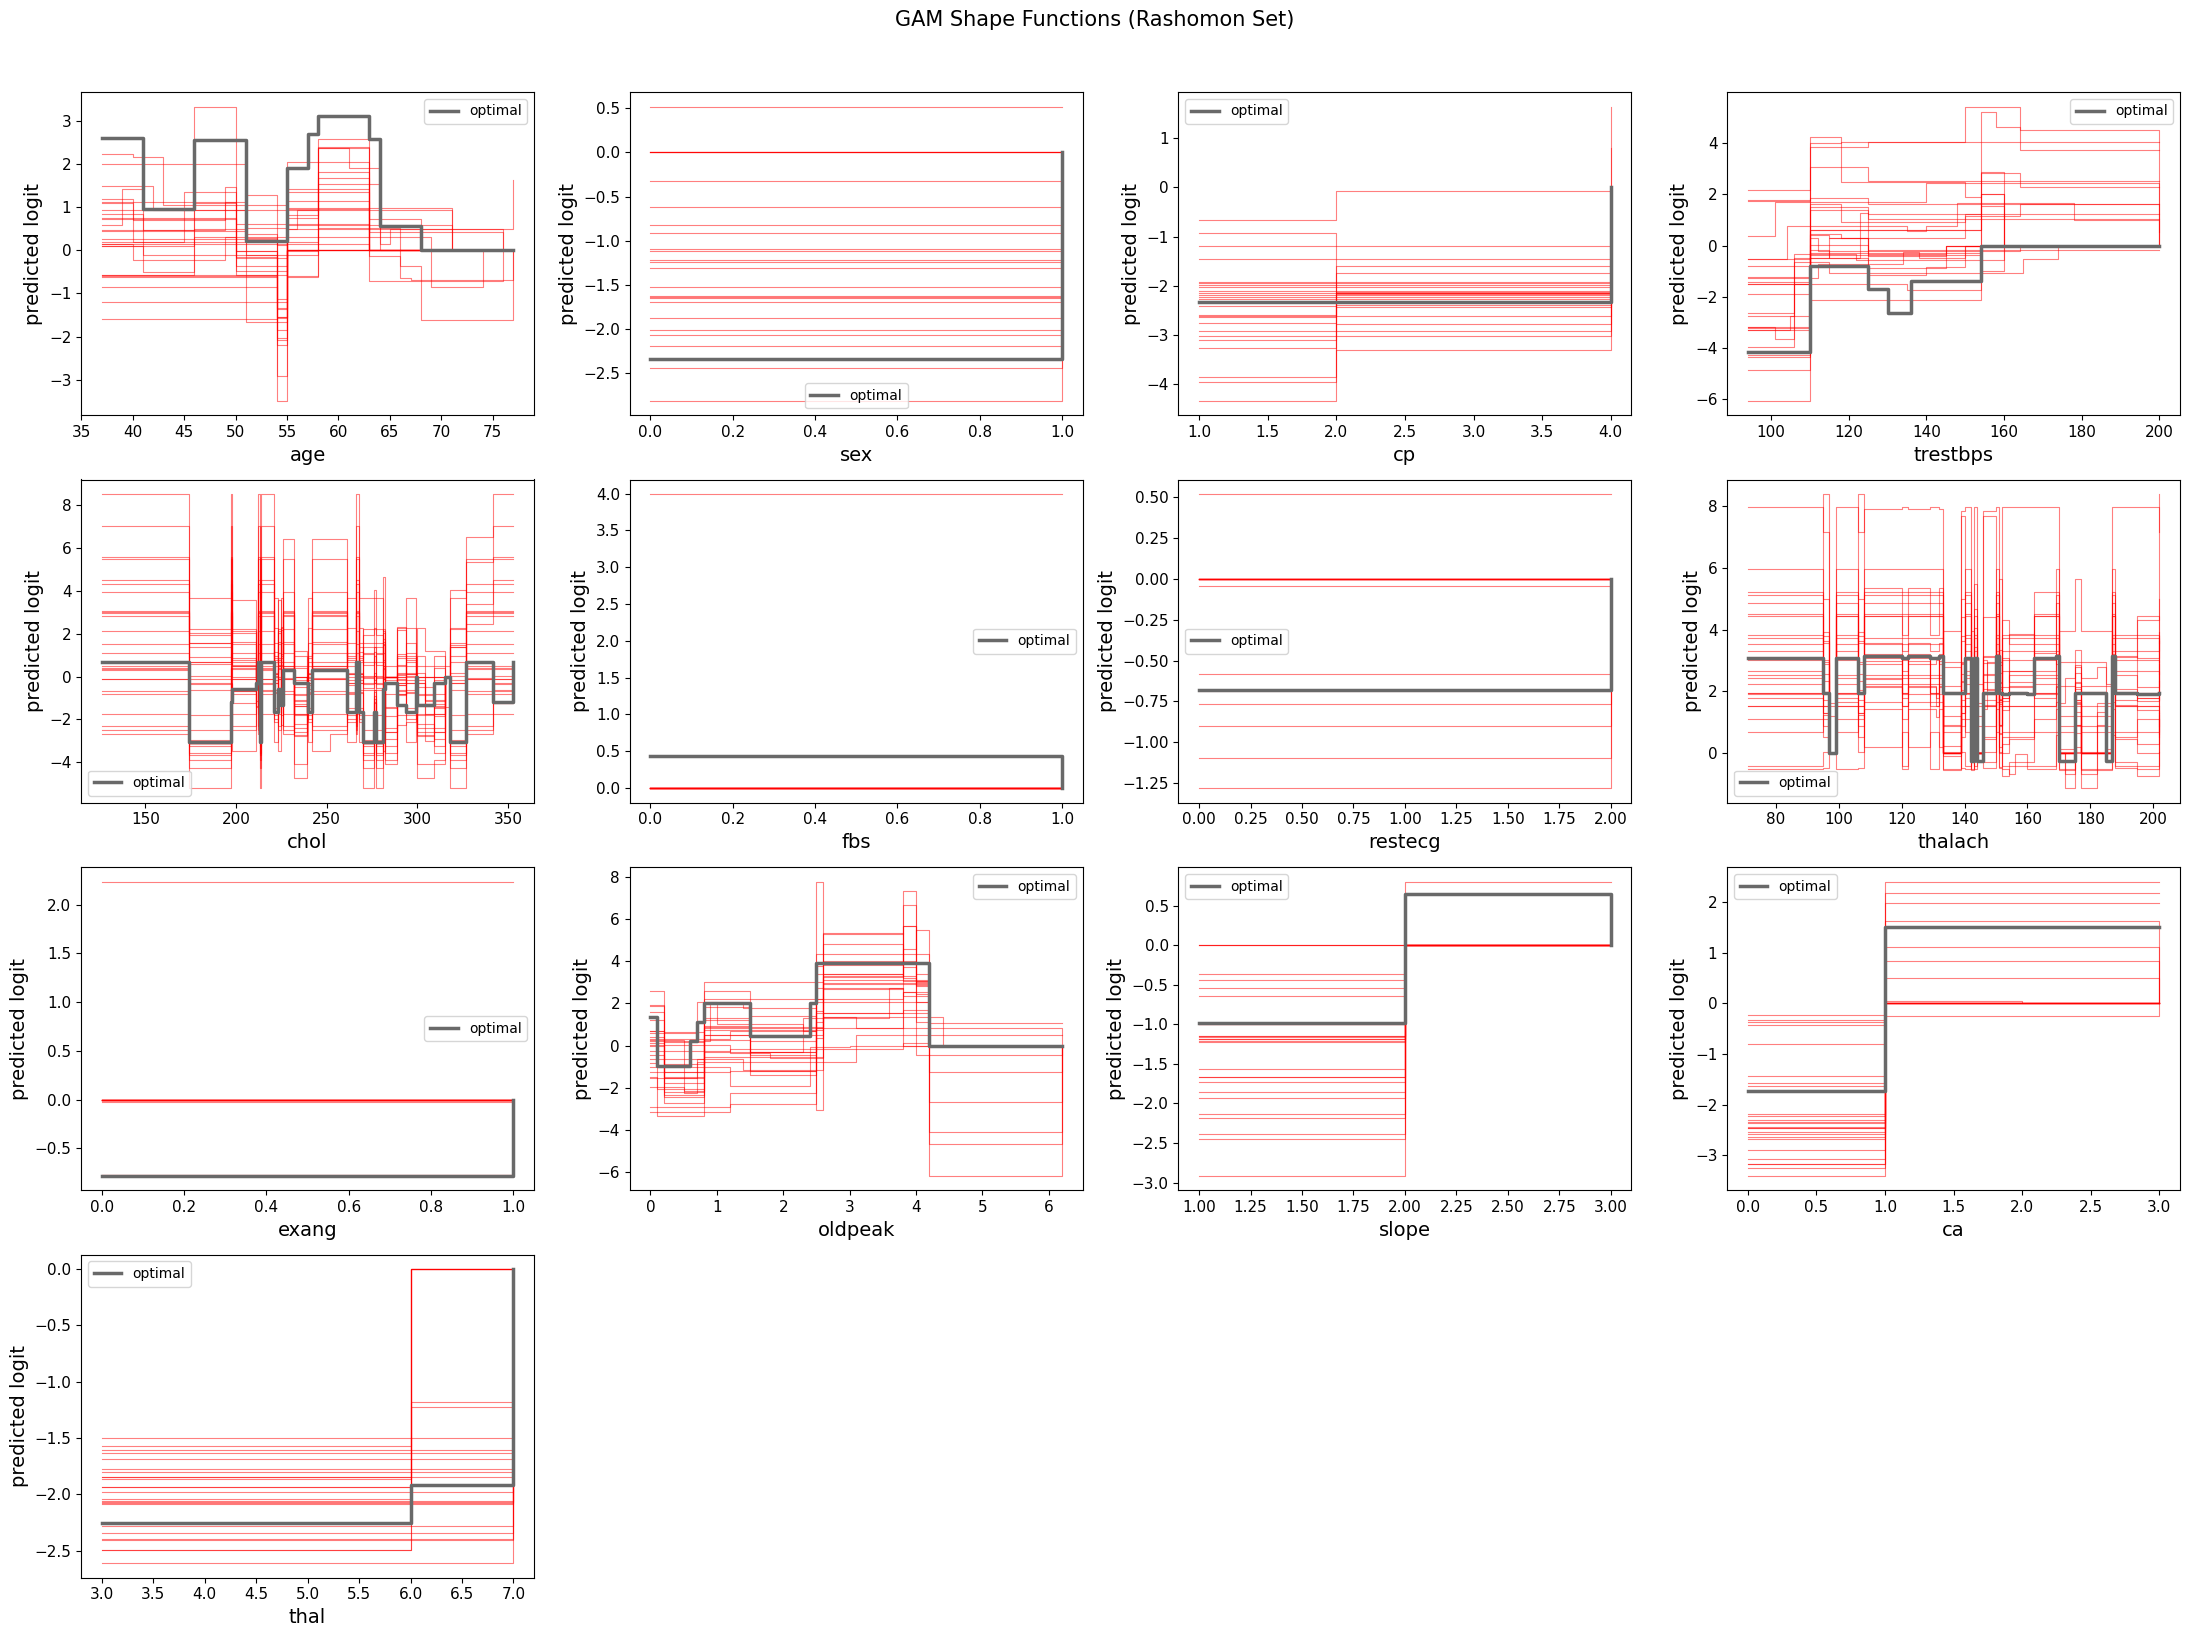

In [8]:
from typing import List, Tuple, Optional, Callable, Dict, Any
from functools import partial

plot_gam_shapes(result, feature_groups, data, max_models=100, alpha=0.5, normalize=False, feature_names=feature_names)


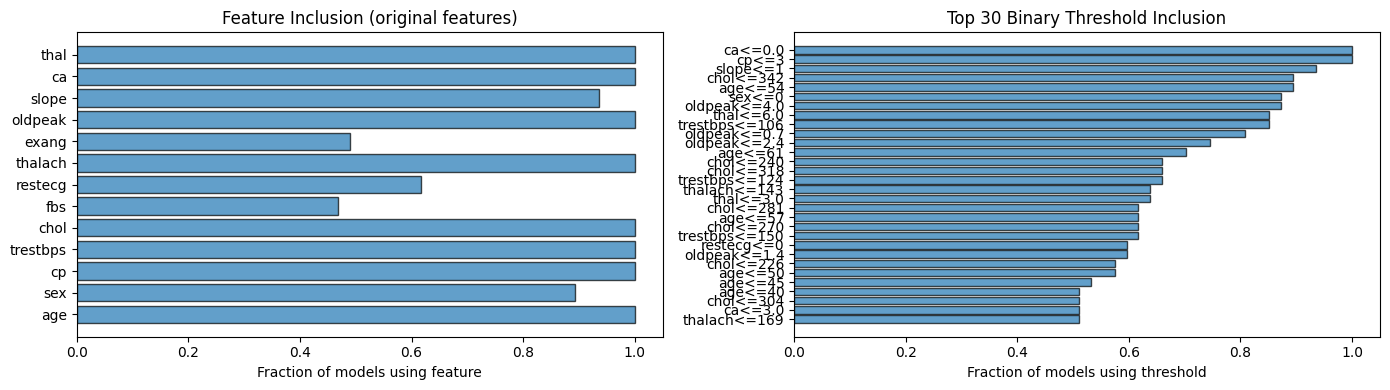

In [9]:
# Feature inclusion: aggregate to original-feature level
inclusion = (result.w_models != 0).mean(axis=0)
group_inclusion = {}
for feat, indices in feature_groups.items():
    group_inclusion[feat] = (result.w_models[:, indices] != 0).any(axis=1).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

feats = list(group_inclusion.keys())
vals = [group_inclusion[f] for f in feats]
axes[0].barh(feats, vals, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Fraction of models using feature')
axes[0].set_title('Feature Inclusion (original features)')

top_k = min(30, len(feature_names))
top_idx = np.argsort(inclusion)[::-1][:top_k]
axes[1].barh([feature_names[i] for i in top_idx], inclusion[top_idx],
             edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Fraction of models using threshold')
axes[1].set_title(f'Top {top_k} Binary Threshold Inclusion')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
from new_method_scripts.ellipsoid import EllipsoidSampler
best_model_mcmc = result.w_opt
preds_best_model = 1/(1+np.exp(-X@best_model_mcmc))
best_err = float(np.mean((preds_best_model >= 0.5).astype(float) != y))
print(best_err, result.best_error)
eps = 0.5
print(f'MCMC best error: {best_err:.4f}')
# Use the same eps/sigma2 as MCMC, and center on the MCMC optimal model
ell = EllipsoidSampler(X, y, eps=sampler.eps, sigma2=sampler.sigma2)
ell_result = ell.sample(n_samples=200, w_center=result.w_models[0], sampling='uniform',rashomon_bound=best_err*(1+eps))

print(f'\nMCMC: {result.n_accepted} models, best error {result.best_error:.4f}')
print(f'Ellipsoid: {ell_result.n_accepted} models, best error {ell_result.best_error:.4f}')

plot_gam_shapes(ell_result, feature_groups, data, max_models=200, alpha=0.25, normalize=False, feature_names=feature_names)

0.07590759075907591 0.07590759075907591
MCMC best error: 0.0759
Support: 32 features, MAP error: 0.1122
Ellipsoid ub=0.15, sampling 200 candidates...
Best error: 0.1122, bound: 0.1139
Rashomon set: 41/200 (20.5% acceptance), runtime: 0.2s

MCMC: 47 models, best error 0.0759
Ellipsoid: 41 models, best error 0.1122


In [12]:
from new_method_scripts.diversity_measures import diversity_summary, pairwise_hamming, pairwise_shape_distance, pairwise_prediction_hamming

mcmc_div = diversity_summary(result, feature_groups, X=X, label='MCMC')
ell_div = diversity_summary(ell_result, feature_groups, X=X, label='Ellipsoid')

all_keys = list(mcmc_div.keys())
print(f'\n{"Metric":<30} {"MCMC":>10} {"Ellipsoid":>10}')
print('-' * 52)
for key in all_keys:
    m = mcmc_div.get(key, float('nan'))
    e = ell_div.get(key, float('nan'))
    print(f'{key:<30} {m:>10.4f} {e:>10.4f}')


Diversity summary (MCMC)  [47 models]
  Pairwise Hamming (support)   : 0.1835
  Pairwise Hamming (prediction): 0.0747
  Pairwise shape L1 distance   : 1.1840
  Pairwise weight L1 distance  : 0.2824
  Pairwise structural distance : 0.2158
  Monotonicity entropy (avg)   : 0.1371
                     age:  inc 2%  dec 0%  non 98%  flat 0%  H=0.094
                     sex:  inc 100%  dec 0%  non 0%  flat 13%  H=-0.000
                      cp:  inc 98%  dec 0%  non 2%  flat 0%  H=0.094
                trestbps:  inc 4%  dec 0%  non 96%  flat 0%  H=0.160
                    chol:  inc 2%  dec 0%  non 98%  flat 0%  H=0.094
                     fbs:  inc 0%  dec 100%  non 0%  flat 55%  H=-0.000
                 restecg:  inc 100%  dec 0%  non 0%  flat 40%  H=-0.000
                 thalach:  inc 0%  dec 11%  non 89%  flat 0%  H=0.308
                   exang:  inc 100%  dec 0%  non 0%  flat 55%  H=-0.000
                 oldpeak:  inc 2%  dec 0%  non 98%  flat 0%  H=0.094
                   

TypeError: unsupported format string passed to dict.__format__

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(12, 14))

ham_mcmc, _ = pairwise_hamming(result)
ham_ell, _ = pairwise_hamming(ell_result)
shape_mcmc, _ = pairwise_shape_distance(result, feature_groups)
shape_ell, _ = pairwise_shape_distance(ell_result, feature_groups)
pred_mcmc, _ = pairwise_prediction_hamming(result, X)
pred_ell, _ = pairwise_prediction_hamming(ell_result, X)

for ax, mat, title in [
    (axes[0, 0], ham_mcmc, 'MCMC: Support Hamming'),
    (axes[0, 1], ham_ell, 'Ellipsoid: Support Hamming'),
    (axes[1, 0], pred_mcmc, 'MCMC: Prediction Hamming'),
    (axes[1, 1], pred_ell, 'Ellipsoid: Prediction Hamming'),
    (axes[2, 0], shape_mcmc, 'MCMC: Shape L1 distance'),
    (axes[2, 1], shape_ell, 'Ellipsoid: Shape L1 distance'),
]:
    im = ax.imshow(mat, cmap='viridis', aspect='auto')
    ax.set_title(title, fontsize=12)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


## 3d. Permutation Importance Range

For each original feature, permutation importance = increase in misclassification
error when that feature's columns are randomly shuffled. We compare the range of
this quantity across MCMC vs Ellipsoid models.

In [ ]:
from new_method_scripts.diversity_measures import variable_importance, plot_variable_importance

vi_mcmc = variable_importance(result, feature_groups, X, y, n_repeats=5)
vi_ell = variable_importance(ell_result, feature_groups, X, y, n_repeats=5)

# Side-by-side comparison table
feats = list(feature_groups.keys())
print(f'{"Feature":<30} {"MCMC":^36} | {"Ellipsoid":^36}')
print(f'{"":<30} {"min":>8} {"max":>8} {"mean":>8} {"std":>8} | {"min":>8} {"max":>8} {"mean":>8} {"std":>8}')
print('-' * 110)
for f in feats:
    m = vi_mcmc[f]
    e = vi_ell[f]
    print(f'{f:<30} {m["min"]:8.4f} {m["max"]:8.4f} {m["mean"]:8.4f} {m["std"]:8.4f} '
          f'| {e["min"]:8.4f} {e["max"]:8.4f} {e["mean"]:8.4f} {e["std"]:8.4f}')


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, max(3, 0.5 * len(feats))))
plot_variable_importance(vi_mcmc, label='MCMC', ax=axes[0])
plot_variable_importance(vi_ell, label='Ellipsoid', ax=axes[1])
plt.tight_layout()
plt.show()


## Test fine tuning strategy - does it lead to runtime improvements?


In [10]:
print(X.shape)

(6907, 59)


In [65]:
from sklearn.linear_model import LogisticRegression
import time
from scipy.optimize import minimize_scalar
import numpy as np
import warnings
# pearson correlation
from scipy.stats import pearsonr
np.random.seed(42)
# add column of ones to X
X = np.hstack([np.ones((X.shape[0], 1)), X])

def fit_logistic(X, y, idxs, sigma2=10.0, max_iter=1000):
    """Fit L2-regularized logistic regression. Returns (theta, probabilities)."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        clf = LogisticRegression(
            penalty="l2", C=sigma2, fit_intercept=False,
            solver="lbfgs", max_iter=max_iter,
        )
        clf.fit(X[:,idxs], y)
    return clf.coef_.ravel(), clf.predict_proba(X[:,idxs])[:, 1]

idxs = np.random.randint(0, X.shape[1], 50)
if 0 not in idxs:
    idxs = np.hstack([0, idxs])
print(idxs)

start_time = time.perf_counter()
theta, proba = fit_logistic(X, y, idxs, sigma2 = 0.1)
end_time = time.perf_counter()
print(f"Time taken: {end_time - start_time} seconds")
print(theta.shape)
print(proba.shape)

feature_mapping = dict(zip(idxs, range(len(idxs))))
print(feature_mapping)

feature_to_add = np.random.choice([i for i in range(X.shape[1]) if i not in idxs])
feature_to_remove = np.random.choice([i for i in range(1,X.shape[1]) if i in idxs])

# Correlation matrix via scipy Pearson (np.corrcoef is equivalent and faster for full matrix)
corr_matrix = np.corrcoef(X.T)
np.fill_diagonal(corr_matrix, 0)
corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)

# Feature in idxs most correlated with any feature NOT in idxs (exclude intercept 0 from removal)
compl_all = [j for j in range(X.shape[1]) if j not in idxs]
idxs_no_intercept = [i for i in idxs if i != 0]
best_in, best_out, best_r = max(
    ((i, j, abs(corr_matrix[i, j])) for i in idxs_no_intercept for j in compl_all),
    key=lambda x: x[2], default=(None, None, 0)
)
print(sorted([(i, j, abs(corr_matrix[i, j])) for i in idxs_no_intercept for j in compl_all],key=lambda x: x[2],reverse=True))
print(f"In-idxs feature most correlated with outside: col {best_in} <-> col {best_out}, |r|={best_r:.4f}")

feature_to_add = best_out if best_out is not None else np.random.choice(compl_all)
feature_to_remove = best_in if best_in is not None else np.random.choice(idxs_no_intercept)
corr, _ = pearsonr(X[:, feature_to_remove], X[:, feature_to_add])
print(f"Swap: remove {feature_to_remove}, add {feature_to_add}, r={corr:.4f}")

x_add = X[:, feature_to_add].astype(np.float64)
w_rem = theta[feature_mapping[feature_to_remove]]
fixed_outcome = X[:, idxs] @ theta - X[:, feature_to_remove] * w_rem
prior_sum_sq = np.dot(theta, theta) - w_rem * w_rem
sigma2 = 0.1
_e = 1e-12
full_refit_time = end_time - start_time

def objective(theta_add: float) -> float:
    theta_add = float(theta_add)
    logits = np.clip(fixed_outcome + x_add * theta_add, -20.0, 20.0)
    p = 1.0 / (1.0 + np.exp(-logits))
    nll = -np.sum(y * np.log(p + _e) + (1 - y) * np.log(1 - p + _e))
    prior = 0.5 * (prior_sum_sq + theta_add * theta_add) / sigma2
    return nll + prior

# Finetune: optimize only the new coefficient
start_time = time.perf_counter()
res = minimize_scalar(objective, method="brent", options={"maxiter": 500})
finetune_time = time.perf_counter() - start_time
theta_add_opt = res.x
print(f"Finetune time: {finetune_time:.4f}s  (speedup: {full_refit_time/finetune_time:.1f}x)")

# Build theta_p for proposed support
idxs_new = np.sort(np.array([j for j in idxs if j != feature_to_remove] + [feature_to_add]))
theta_p = np.zeros(len(idxs_new))
for i, j in enumerate(idxs_new):
    if j == feature_to_add:
        theta_p[i] = theta_add_opt
    else:
        theta_p[i] = theta[feature_mapping[j]]

# Compare: full refit vs finetune
theta_full, proba_full = fit_logistic(X, y, idxs_new, sigma2=sigma2)
proba_finetune = 1.0 / (1.0 + np.exp(-np.clip(X[:, idxs_new] @ theta_p, -20.0, 20.0)))
nll_full = -np.sum(y * np.log(proba_full + _e) + (1 - y) * np.log(1 - proba_full + _e))
nll_original = -np.sum(y * np.log(proba + _e) + (1 - y) * np.log(1 - proba + _e))
nll_finetune = -np.sum(y * np.log(proba_finetune + _e) + (1 - y) * np.log(1 - proba_finetune + _e))
print(f"NLL full refit: {nll_full:.4f}, NLL finetune: {nll_finetune:.4f}, NLL original: {nll_original:.4f}")
print(f"Max |theta_full - theta_finetune|: {np.max(np.abs(theta_full - theta_p)):.6f}")


print(theta_full, theta_full.shape)
print(theta_p)
print(theta_add_opt, w_rem)



[ 0 51 92 14 71 60 20 82 86 74 74 87 23  2 21 52  1 87 29 37  1 63 59 20
 32 75 57 21 88 48 90 58 41 91 59 79 14 61 61 46 61 50 54 63  2 50  6 20
 72 38 17]
Time taken: 1.7828902639448643 seconds
(51,)
(6907,)
{0: 0, 51: 1, 92: 2, 14: 36, 71: 4, 60: 5, 20: 47, 82: 7, 86: 8, 74: 10, 87: 17, 23: 12, 2: 44, 21: 27, 52: 15, 1: 20, 29: 18, 37: 19, 63: 43, 59: 34, 32: 24, 75: 25, 57: 26, 88: 28, 48: 29, 90: 30, 58: 31, 41: 32, 91: 33, 79: 35, 61: 40, 46: 39, 50: 45, 54: 42, 6: 46, 72: 48, 38: 49, 17: 50}


/usr/project/xtmp/vb97/GAM_Rashomon_Sets/gams/lib/python3.9/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/project/xtmp/vb97/GAM_Rashomon_Sets/gams/lib/python3.9/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


[(86, 30, 1.0), (29, 83, 1.0), (41, 42, 0.9438793824469338), (41, 40, 0.941978386904029), (71, 70, 0.895891939241539), (82, 81, 0.8943624032564634), (41, 39, 0.8870394557090505), (79, 78, 0.8794351566691306), (46, 45, 0.8685565980397673), (38, 39, 0.8564954107059822), (41, 43, 0.8532965698205688), (52, 53, 0.8162598466284874), (48, 47, 0.8115574628380009), (72, 70, 0.8080758533503593), (38, 40, 0.8065420963924298), (71, 69, 0.8045081891402588), (41, 44, 0.7702501278224829), (72, 73, 0.7695244555860331), (74, 73, 0.7620774206452963), (74, 73, 0.7620774206452963), (46, 47, 0.7524901787499435), (37, 39, 0.7262363591938096), (72, 69, 0.7256496157530371), (71, 68, 0.7231102762360346), (38, 42, 0.7171078518361137), (37, 36, 0.710228742851375), (75, 76, 0.7089856286950531), (54, 53, 0.706901882085993), (75, 73, 0.7033156644650881), (71, 73, 0.6940950173612475), (48, 49, 0.6858542353395645), (37, 40, 0.6838801332721371), (46, 44, 0.6747186093625185), (74, 76, 0.6543176389081661), (74, 76, 0.65

In [ ]:
# Correlation analysis (uses corr_matrix from above)
# Feature in idxs most highly correlated with any feature NOT in idxs
idxs_set = set(idxs)
compl = [j for j in range(X.shape[1]) if j not in idxs_set]
best_in_idxs, best_out_idxs, best_corr = max(
    ((i, j, abs(corr_matrix[i, j])) for i in idxs for j in compl),
    key=lambda x: x[2], default=(None, None, -1)
)
print(f"Feature in idxs most correlated with outside: col {best_in_idxs} <-> col {best_out_idxs}, |r| = {best_corr:.4f}")

# Overall most correlated pair (any two distinct features)
mask = np.abs(corr_matrix)
mask[np.diag_indices_from(mask)] = 0
i_max, j_max = np.unravel_index(np.argmax(mask), mask.shape)
print(f"Overall most correlated pair: cols ({i_max}, {j_max}), |r| = {abs(corr_matrix[i_max, j_max]):.4f}")